In [ ]:
''' SETUP '''
import os 
os.chdir("/Users/muberraozmen/Development/psycho-pass")

from copy import deepcopy
import json
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

def get_config_value(config, key):
    config = deepcopy(config)
    key = key.split(".")
    for k in key:
        config = config[k]
    
    if "airt" in config:
        config = "airt"
    
    if "deepseek" in config:
        config = "deepseek"
    if "gemma" in config:
        config = "gemma"
    if "qwen" in config:
        config = "qwen"
    if "mistral" in config:
        config = "mistral"
    if "gpt-oss" in config:
        config = "gpt-oss"
    if "llama" in config:
        config = "llama"
        
    return config

METRIC_NAMES = ["distance", "displacement", "speed", "speed_std", "velocity", "directness", "circularity"]
def load_metrics(experiment_dir: Path, filename: str) -> pd.DataFrame:
    config = json.load(open(experiment_dir / "config.json"))
    metrics = pd.read_csv(experiment_dir / filename)
    metrics.rename(columns={
        "conversation_id": "ID",
        "outcome": "Outcome", 
        "executed_turns": "Number of Turns",
        }, inplace=True)
    metrics["Dataset"] = get_config_value(config, "seeds.dataset_name")
    metrics["Objective Model"] = get_config_value(config, "attack.objective.model_name")

    metrics[METRIC_NAMES] = metrics[METRIC_NAMES].dropna()
    metrics[METRIC_NAMES] = metrics[METRIC_NAMES].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
    
    return metrics[["ID", "Dataset", "Objective Model", "Outcome", "Number of Turns"] + METRIC_NAMES]


sns.set_theme(style="ticks", palette="bright", font="Times", font_scale=1.2, color_codes=True, rc={"lines.linewidth": 1.5})

attack_result_colors = {
    "success": "red",
    "failure": "green",
}


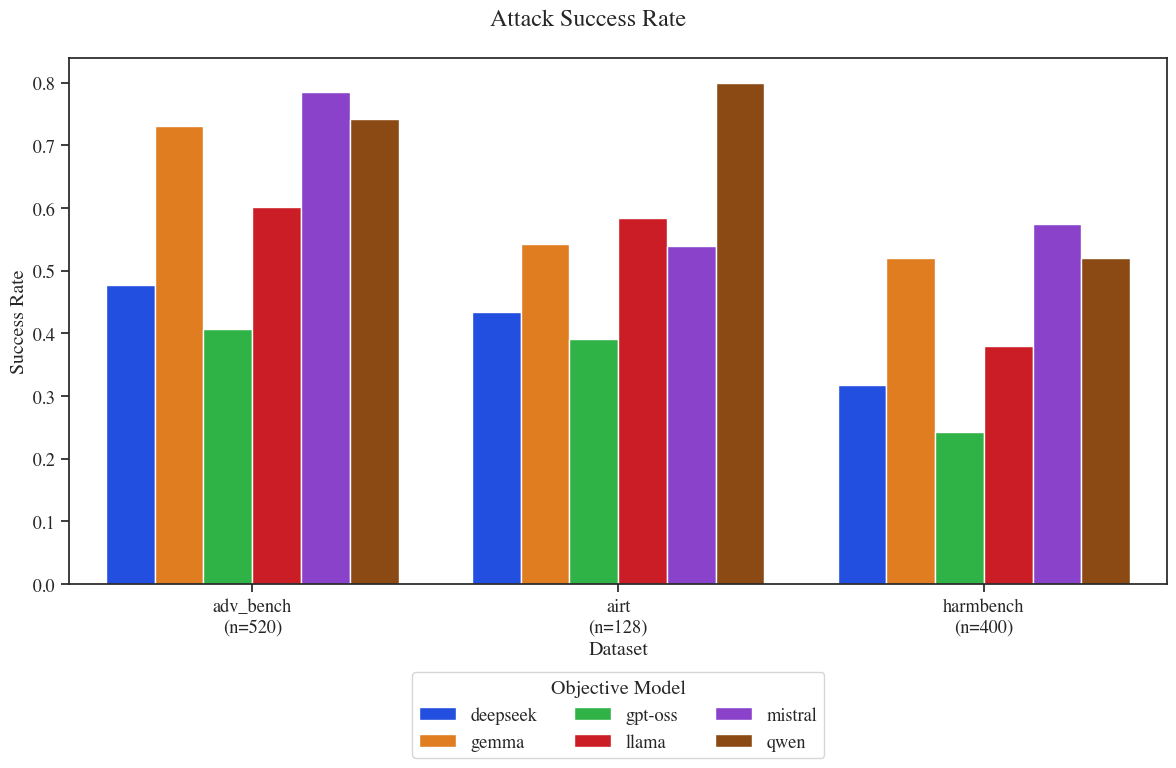

In [2]:
''' Success Rate '''

def load(run_dir: Path) -> pd.DataFrame:
    results = []
    experiments = os.listdir(run_dir)
    for experiment_name in experiments:
        experiment_dir = run_dir / experiment_name
        try:
            results.append(load_metrics(experiment_dir, "metrics_lexical.csv"))
        except Exception:
            continue
            
    results = pd.concat(results)

    results = results.groupby(["Dataset", "Objective Model"])[["Outcome", "ID"]].agg(
        {
            "Outcome": lambda x: x.value_counts().get("success", 0) / len(x),  
            "ID": "count"
        } 
    ).reset_index()

    results.rename(columns={"Outcome": "Success Rate", "ID": "Number of Samples"}, inplace=True)

    return results


def plot(run_dir: Path) -> pd.DataFrame:
    results = load(run_dir)

    plt.figure(figsize=(12, 8))

    g = sns.barplot(
        data=results, 
        order=sorted(results["Dataset"].unique()),
        x="Dataset", 
        y="Success Rate", 
        hue="Objective Model", 
        hue_order=sorted(results["Objective Model"].unique())
    )

    # Add sample size to x-axis labels
    new_labels = []
    for label in g.get_xticklabels():
        dataset_name = label.get_text()
        n_samples = results[results["Dataset"] == dataset_name]["Number of Samples"].max()
        new_labels.append(f"{dataset_name}\n(n={n_samples})")
    g.set_xticks(range(len(new_labels))) 
    g.set_xticklabels(new_labels, rotation=0)

    # Final touches
    plt.suptitle("Attack Success Rate")
    sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.tight_layout()
    
    # Save the plot
    os.makedirs("./plots", exist_ok=True)
    plt.savefig("./plots/success_rates.pdf")
    
    plt.show()


run_path = Path("/Users/muberraozmen/Development/psycho-pass/experiments/objective_model_comparisons")
results = plot(run_path)
results

results

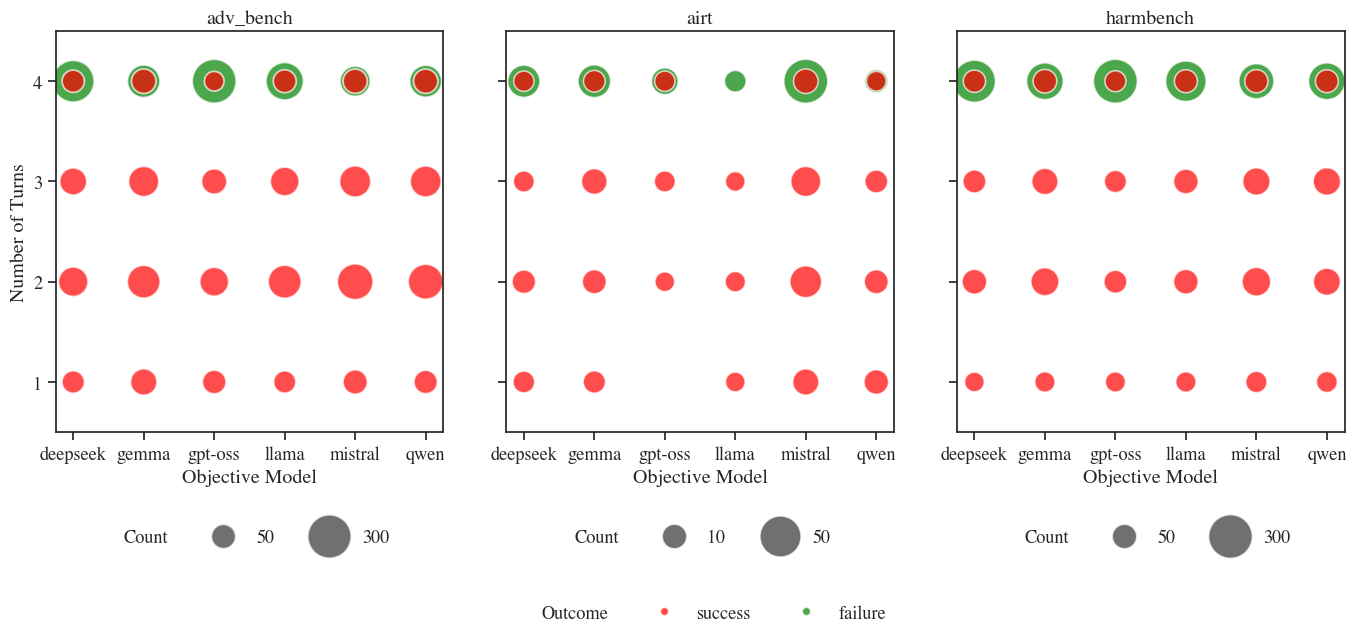

In [3]:
''' Number of Turns '''

def load(run_dir: Path) -> pd.DataFrame:
    results = []
    experiments = os.listdir(run_dir)
    for experiment_name in experiments:
        experiment_dir = run_dir / experiment_name
        try:
            results.append(load_metrics(experiment_dir, "metrics_lexical.csv"))
        except Exception:
            continue
            
    results = pd.concat(results)

    results = results.groupby(["Dataset", "Objective Model", "Outcome", "Number of Turns"]).size().reset_index(name="Count")

    return results

def plot(run_dir: Path):
    results = load(run_dir)

    num_datasets = len(results["Dataset"].unique())
    fig, axs = plt.subplots(1, num_datasets, figsize=(14, 6), sharey=True)
    for i, dataset in enumerate(sorted(results["Dataset"].unique())):
        sns.scatterplot(
            data=results[results["Dataset"] == dataset],
            y="Number of Turns",
            x="Objective Model",
            hue="Outcome",  
            hue_order=["success", "failure"],
            palette=attack_result_colors,
            size="Count",
            sizes=(200, 1000),
            alpha=0.7,
            ax=axs[i],
        )

        axs[i].set_yticks(range(1, results["Number of Turns"].max() + 1))
        axs[i].set_ylim(0.5, results["Number of Turns"].max() + 0.5)
        axs[i].set_title(dataset)
        handles, labels = axs[i].get_legend_handles_labels()
        figure_handles, figure_labels = handles[:3], labels[:3]
        keep = [3, 4, len(handles) - 1]
        axs[i].legend([handles[idx] for idx in keep], [labels[idx] for idx in keep], bbox_to_anchor=(0.0, -0.2), loc='upper left', ncol=3, frameon=False)

    fig.legend(figure_handles, figure_labels, loc='upper center', bbox_to_anchor=(0.5, 0.0), frameon=False, ncol=3)
    plt.tight_layout()

    os.makedirs("./plots", exist_ok=True)
    plt.savefig("./plots/number_of_turns.pdf")

    plt.show()  

run_path = Path("/Users/muberraozmen/Development/psycho-pass/experiments/objective_model_comparisons")
results = plot(run_path)
results

/Users/muberraozmen/Development/psycho-pass/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


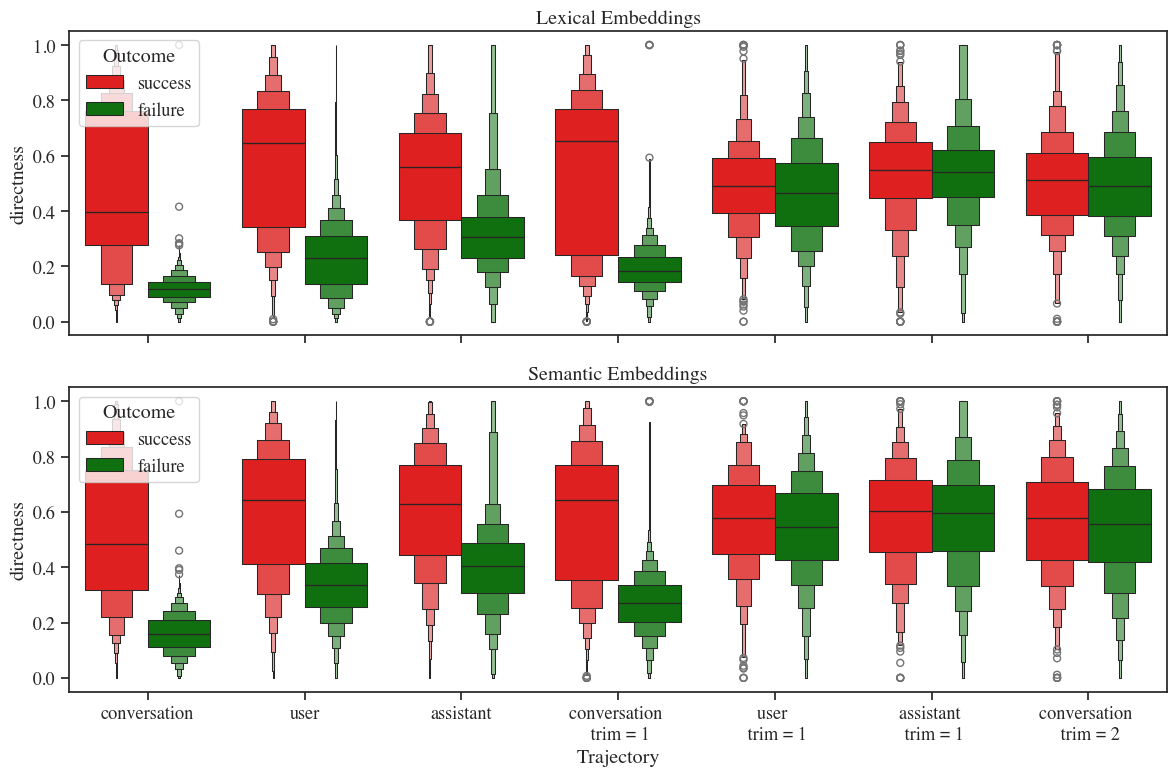

In [4]:
''' Lexical vs Semantic '''

from src.factory import METRICS_CONFIGS

focus_metric = "directness"

def load(run_dir):
    results = {"lexical": [], "semantic": []}
    experiments = os.listdir(run_dir)
    for experiment_name in experiments:
        experiment_dir = run_dir / experiment_name
        try:
            for metric_config in METRICS_CONFIGS:
                try:
                    filename, embeddings, role, trim = metric_config["filename"], metric_config["embeddings"], metric_config["role"], metric_config["trim"]
                    metrics = load_metrics(experiment_dir, filename)

                    if role is None:
                        role = "conversation"
                    trajectory = role
                    if trim is not None:
                        trajectory = f"{trajectory} \n trim = {trim}"
                    metrics["Trajectory"] = trajectory
                    results[embeddings].append(metrics)
                except Exception:
                    continue      
        except Exception:
            continue

    lexical = pd.concat(results["lexical"]).reset_index(drop=True)
    semantic = pd.concat(results["semantic"]).reset_index(drop=True)
    return lexical, semantic

def plot(run_dir: Path):
    lexical, semantic = load(run_dir)

    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    sns.boxenplot(
        data=lexical,
        x="Trajectory",
        y=focus_metric,
        hue="Outcome",
        ax=axs[0],
        palette=attack_result_colors,
    )

    sns.boxenplot(
        data=semantic,
        x="Trajectory",
        y=focus_metric,
        hue="Outcome",
        ax=axs[1],
        palette=attack_result_colors,
    )

    axs[0].set_title("Lexical Embeddings")
    axs[1].set_title("Semantic Embeddings")

    plt.tight_layout()

    os.makedirs("./plots", exist_ok=True)
    plt.savefig("./plots/embeddings_comparison.pdf")

    plt.show()

run_path = Path("/Users/muberraozmen/Development/psycho-pass/experiments/objective_model_comparisons")
results = plot(run_path)




Error plotting metrics_lexical_user_trim2.csv
Error plotting metrics_semantic_user_trim2.csv
Error plotting metrics_lexical_assistant_trim2.csv
Error plotting metrics_semantic_assistant_trim2.csv


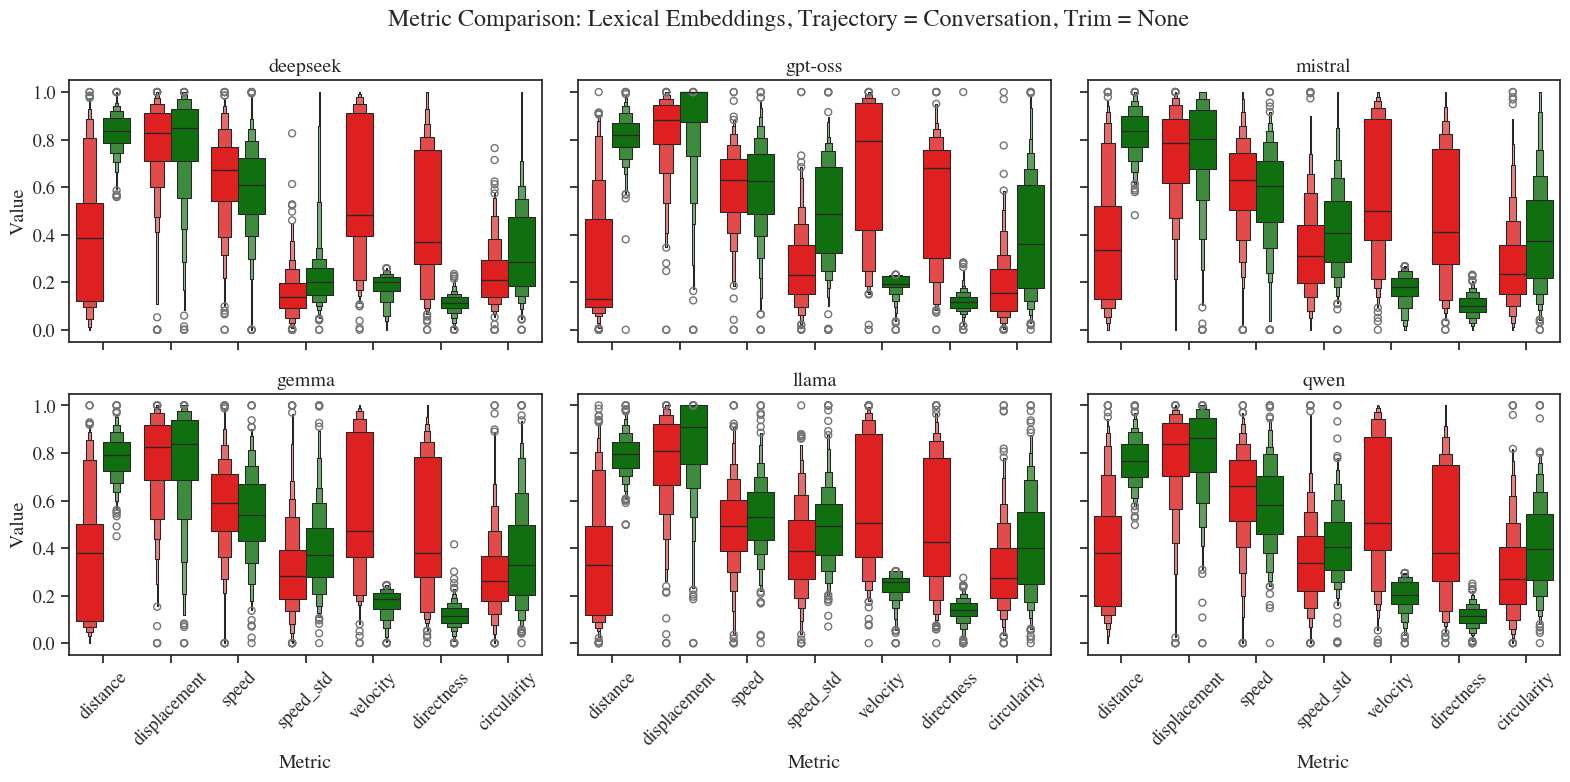

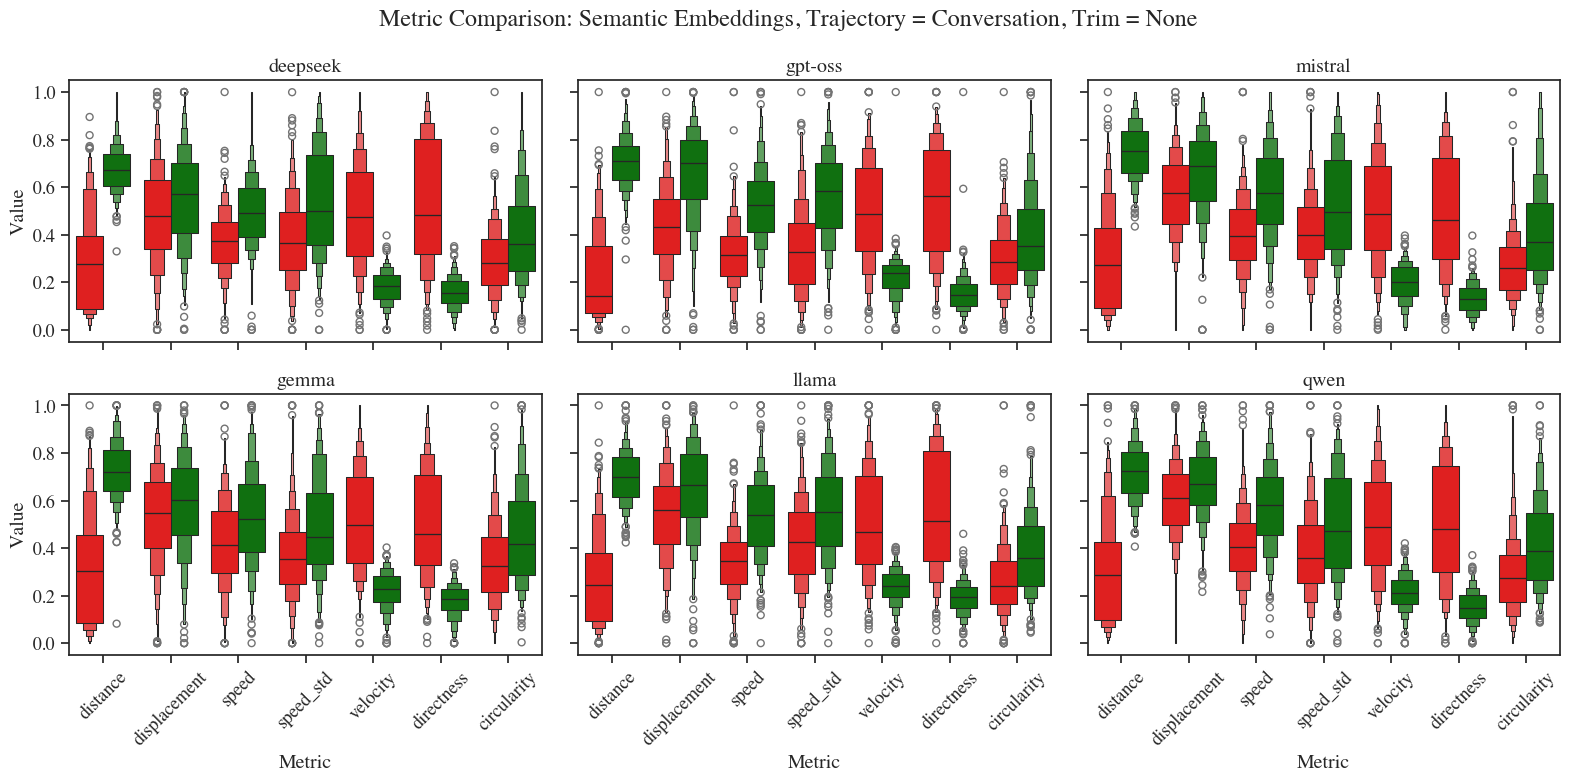

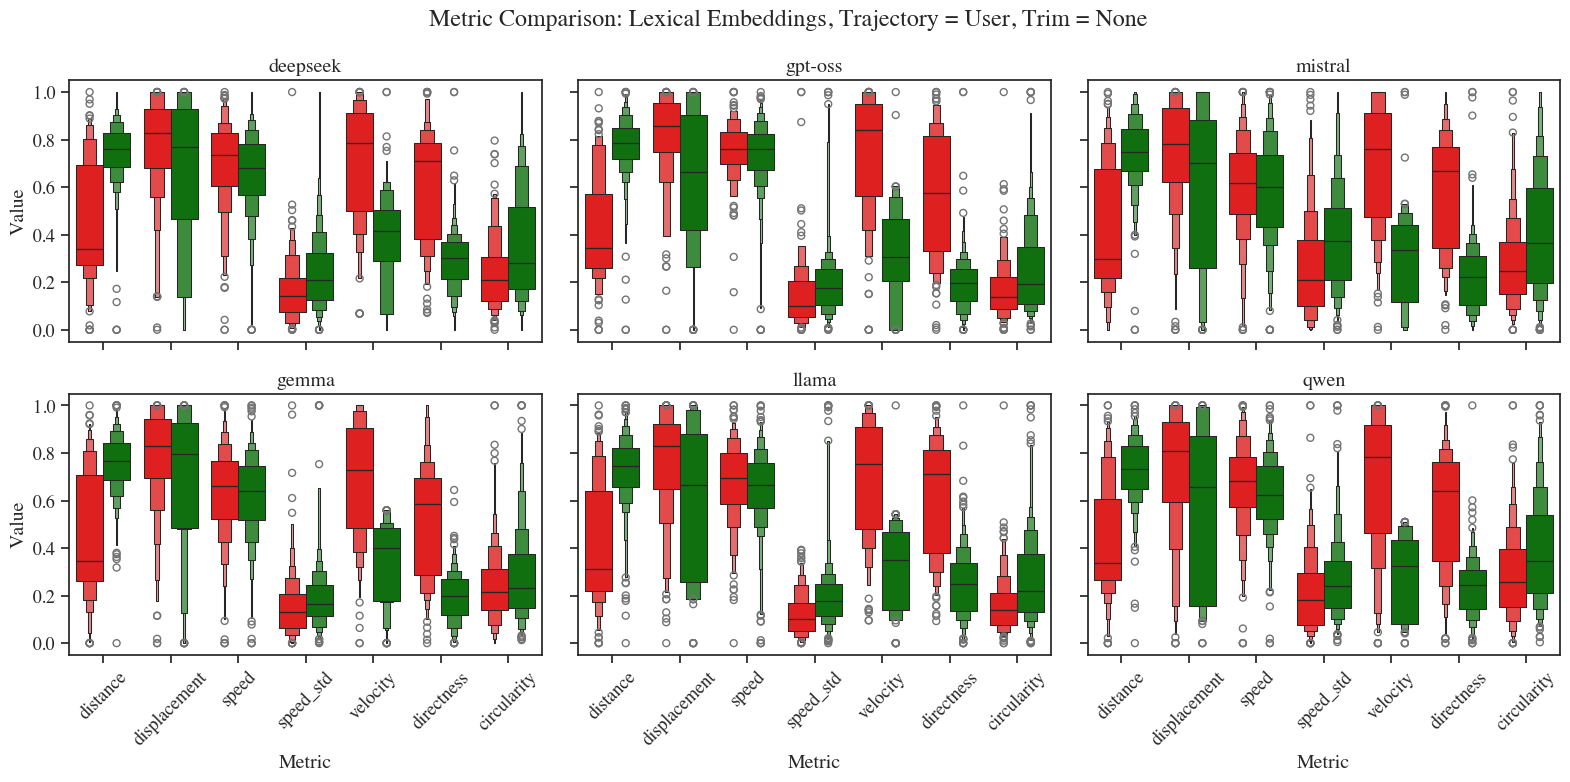

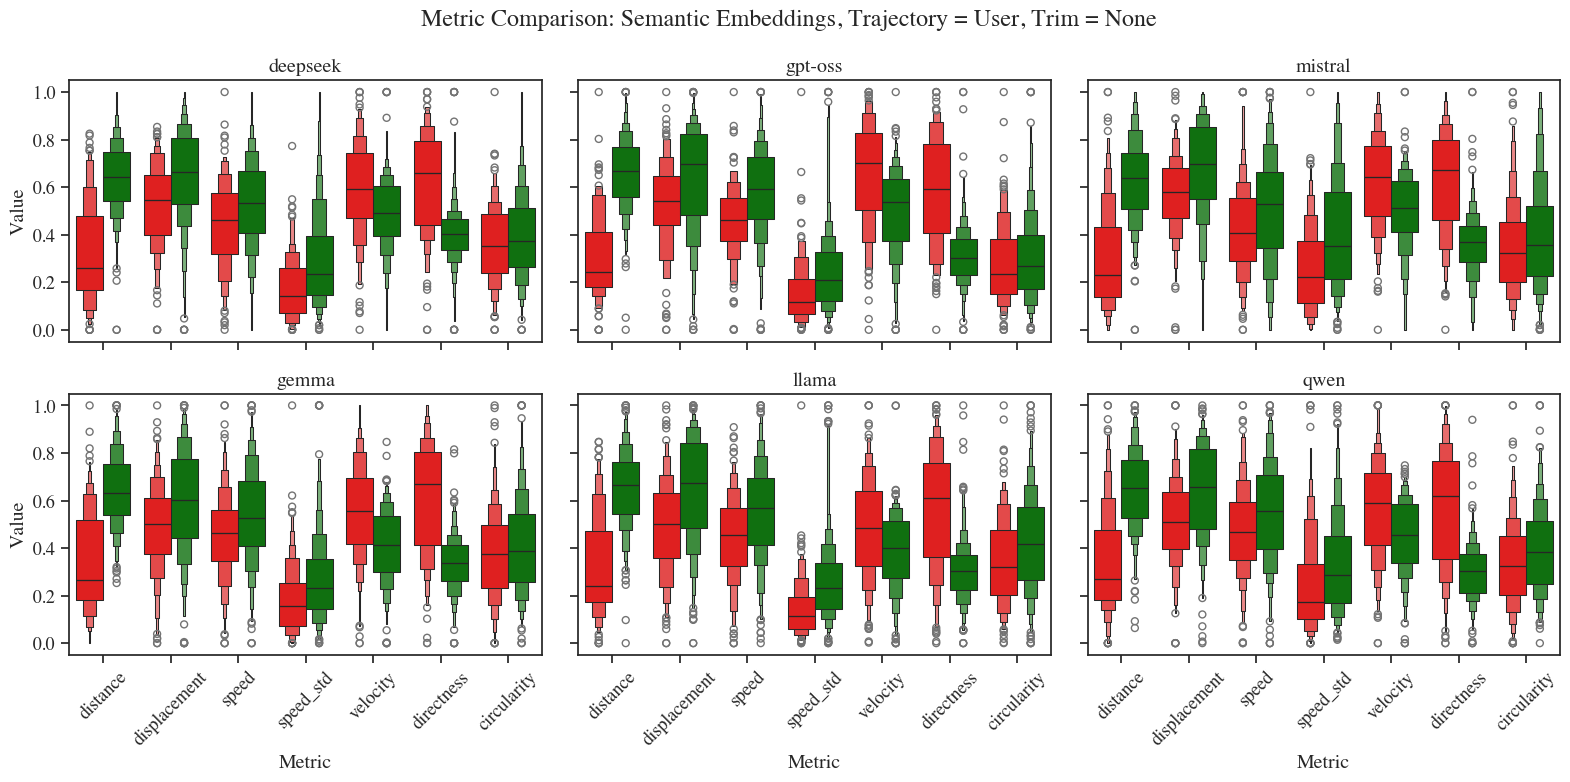

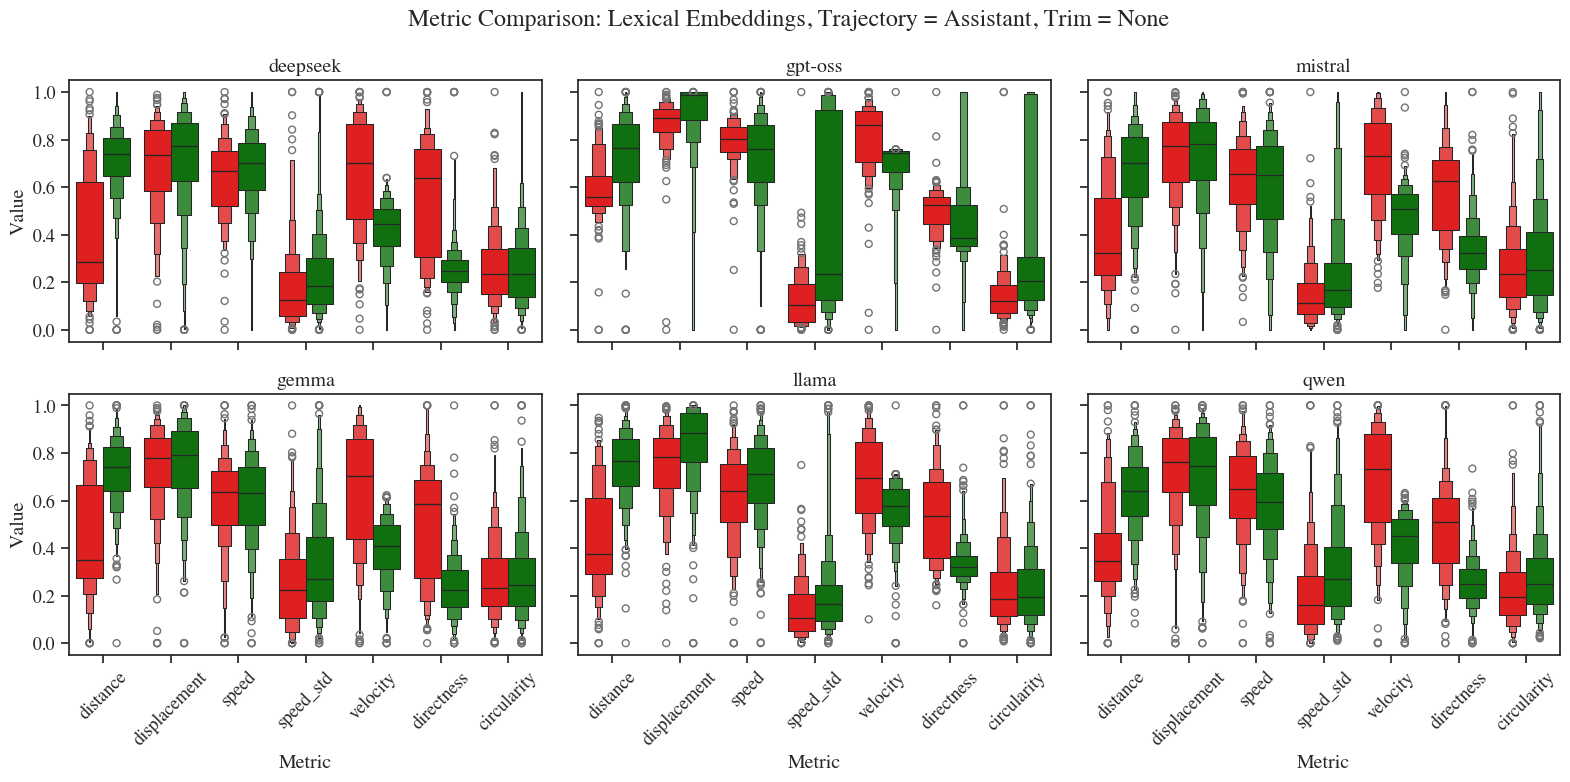

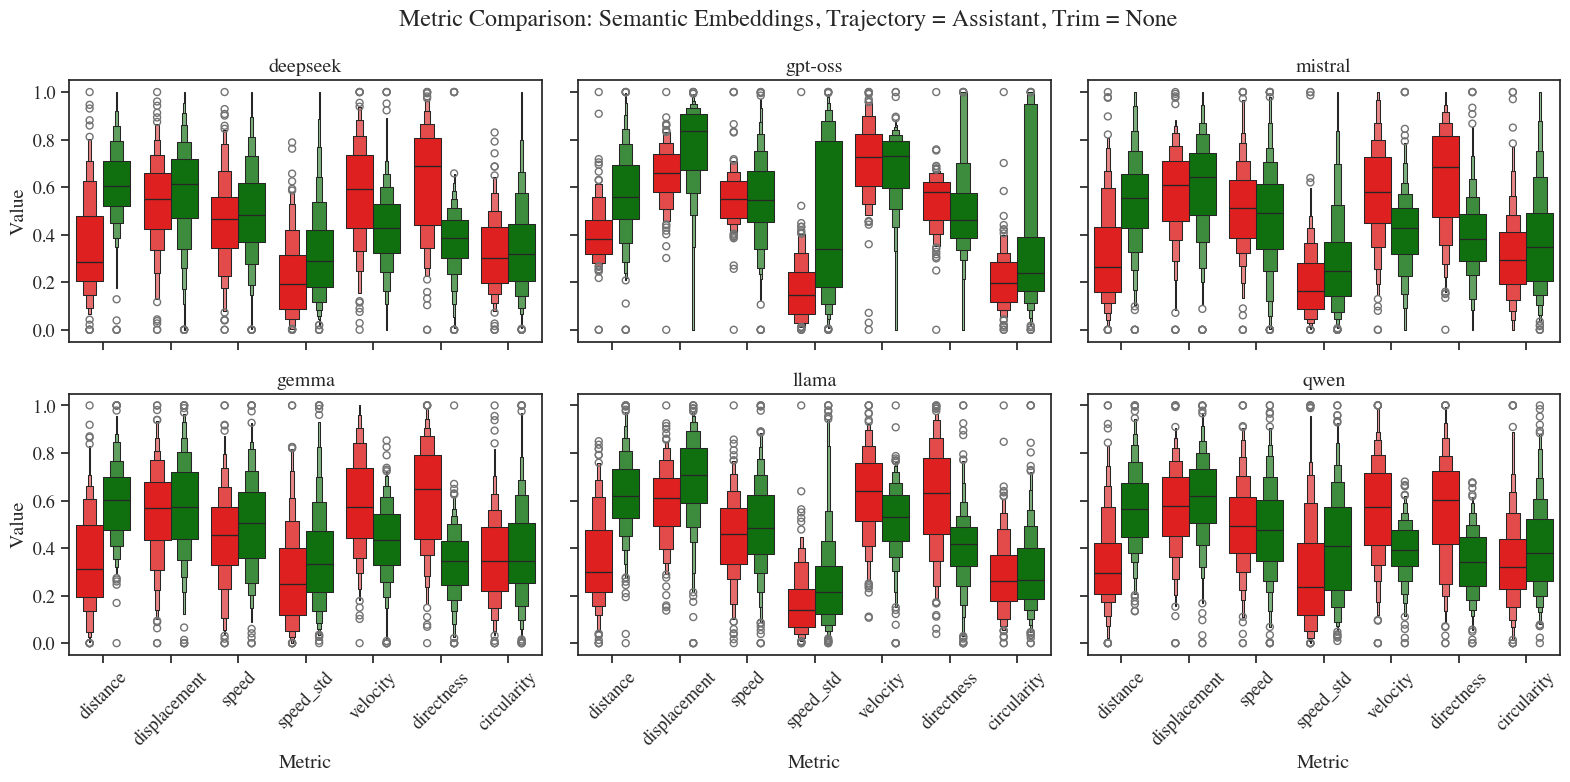

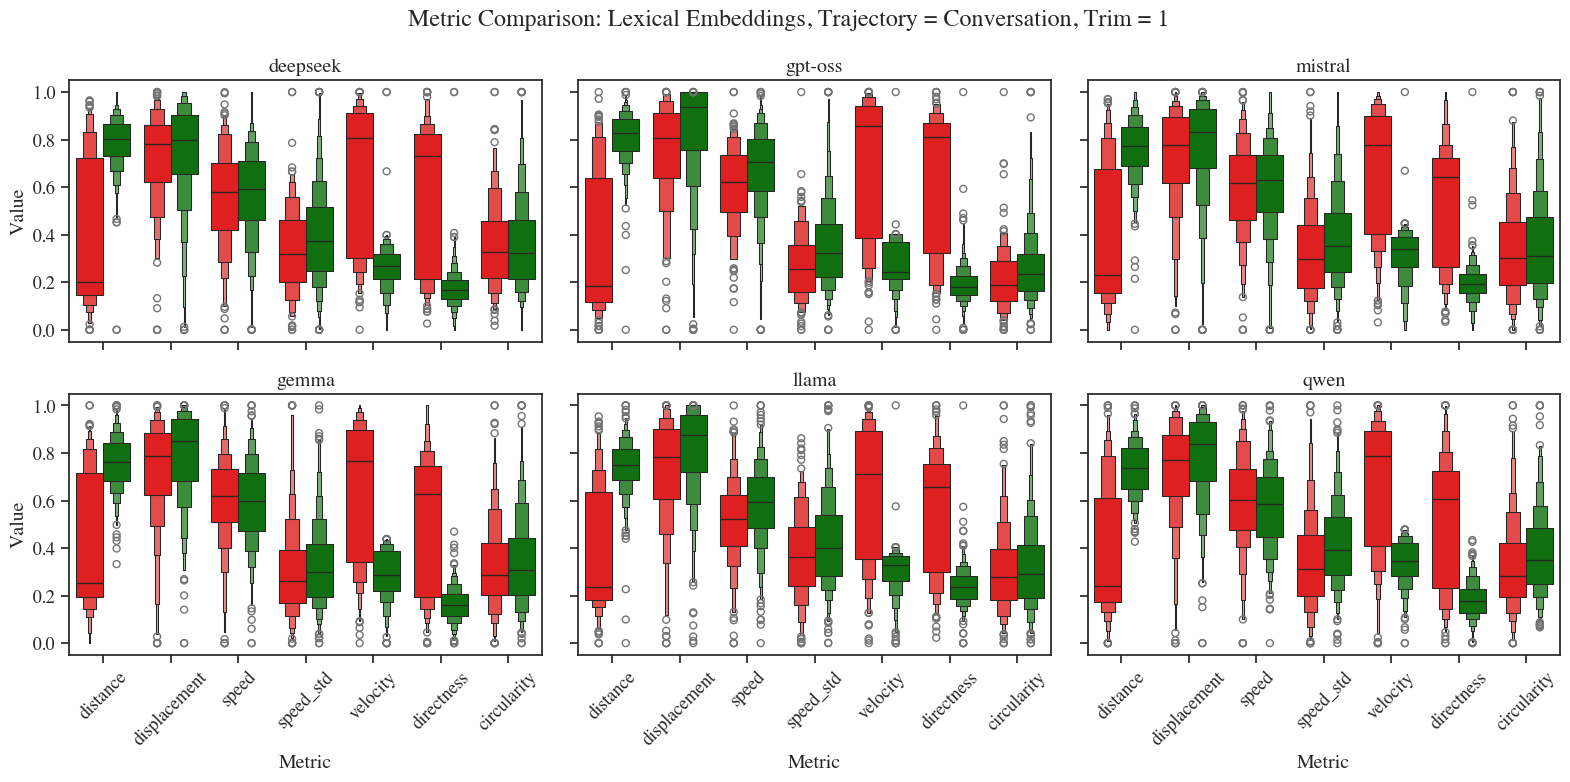

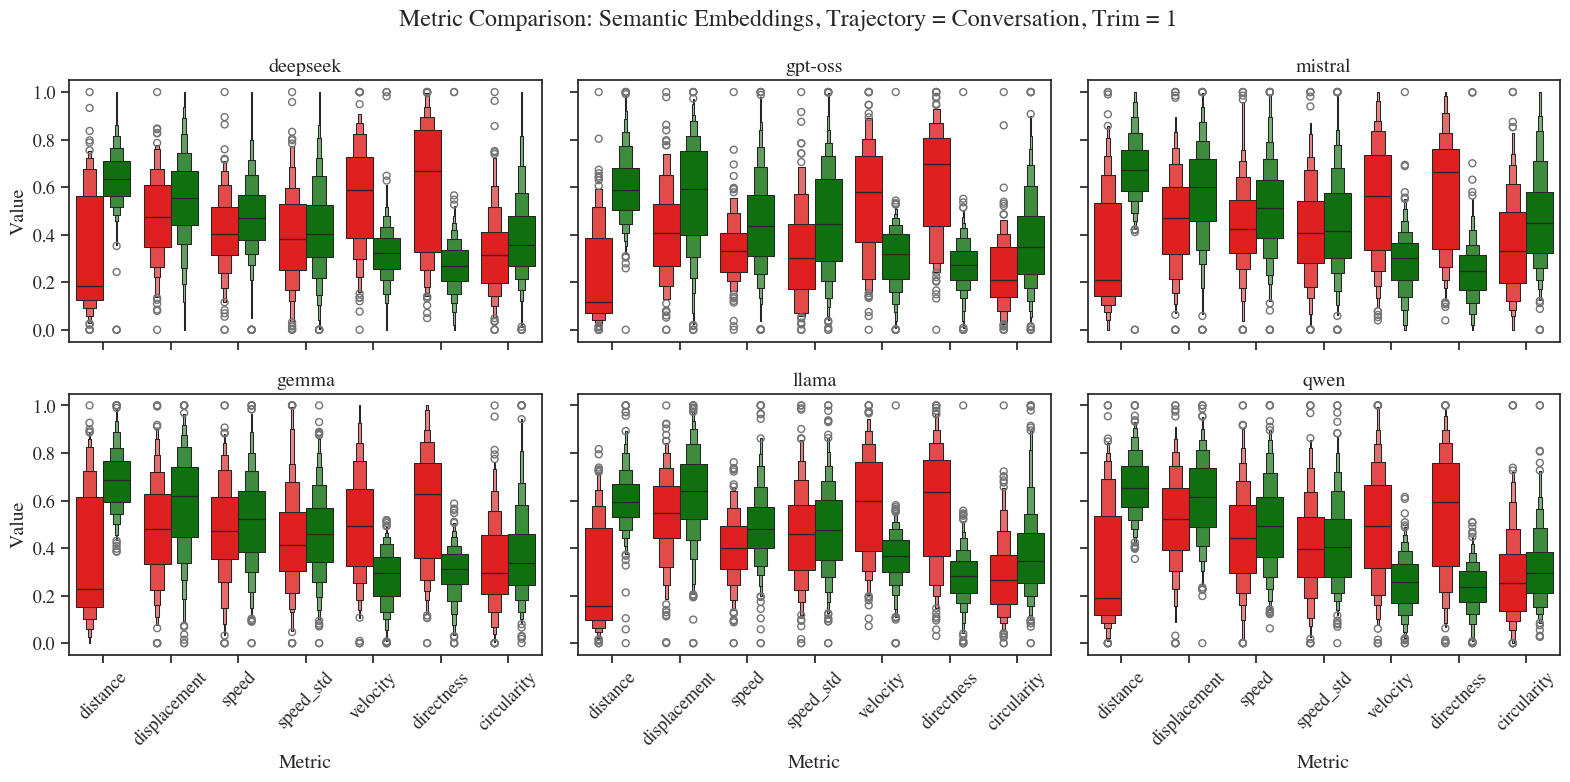

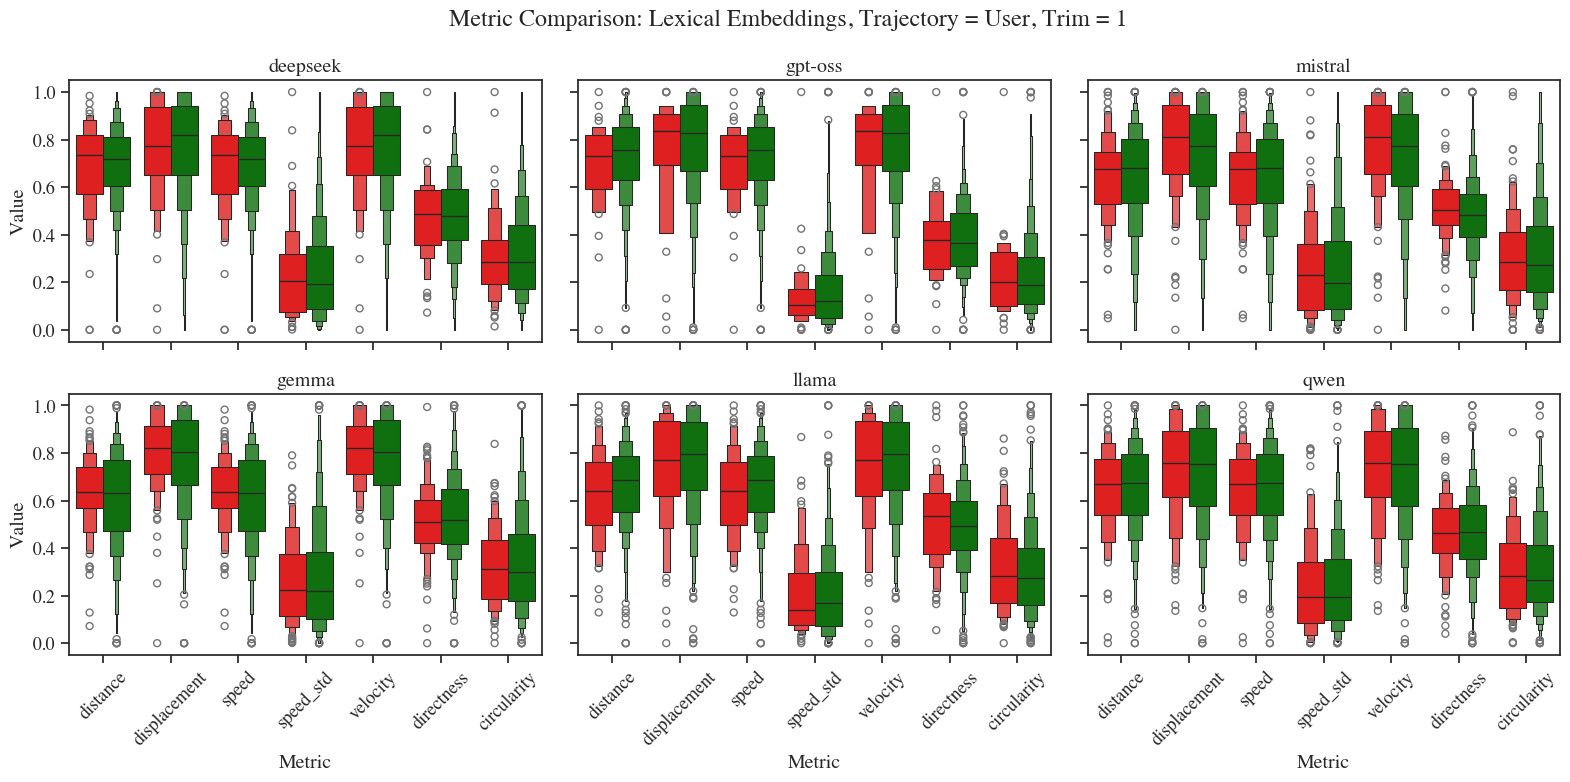

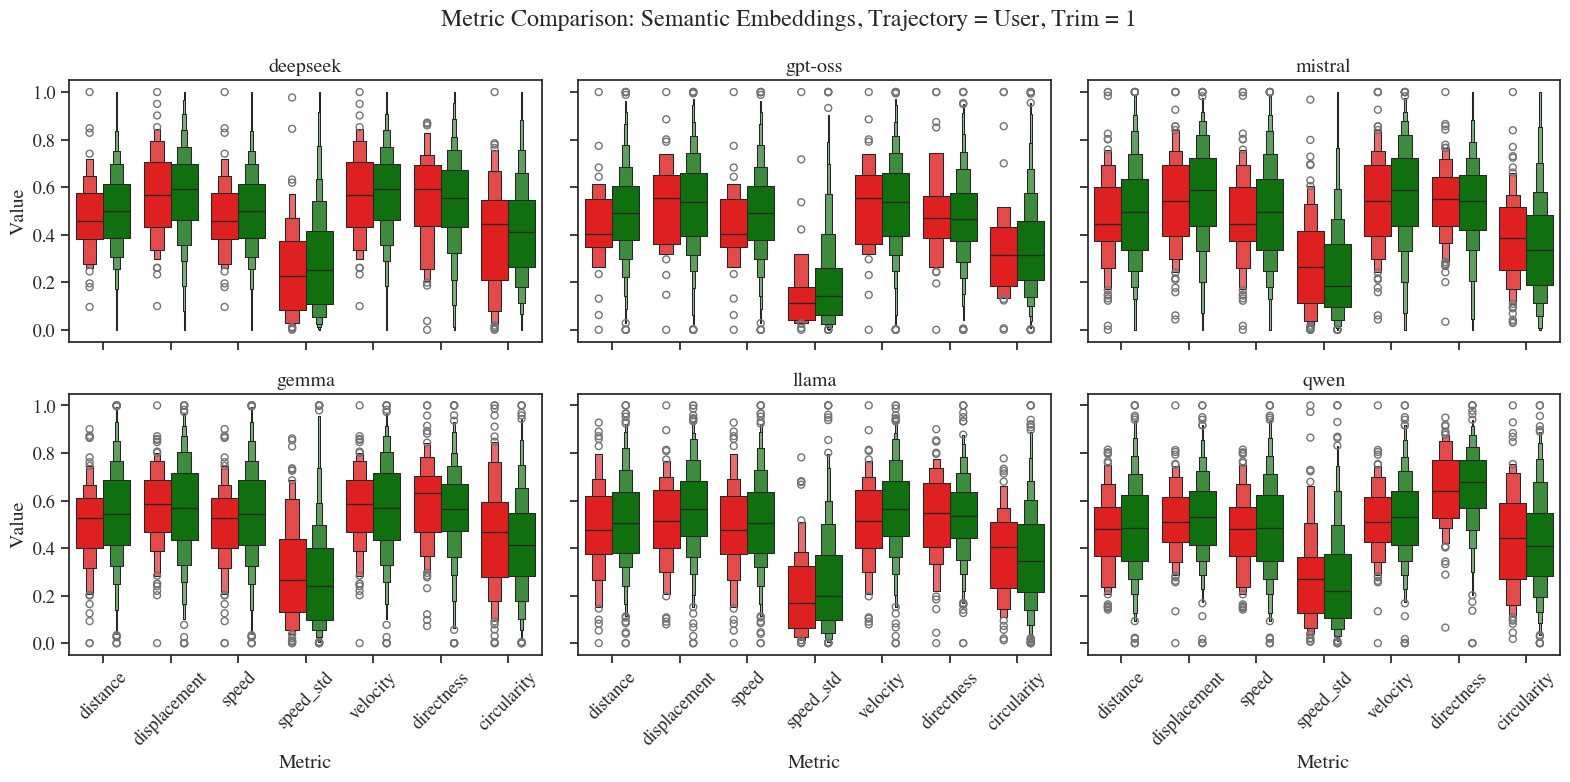

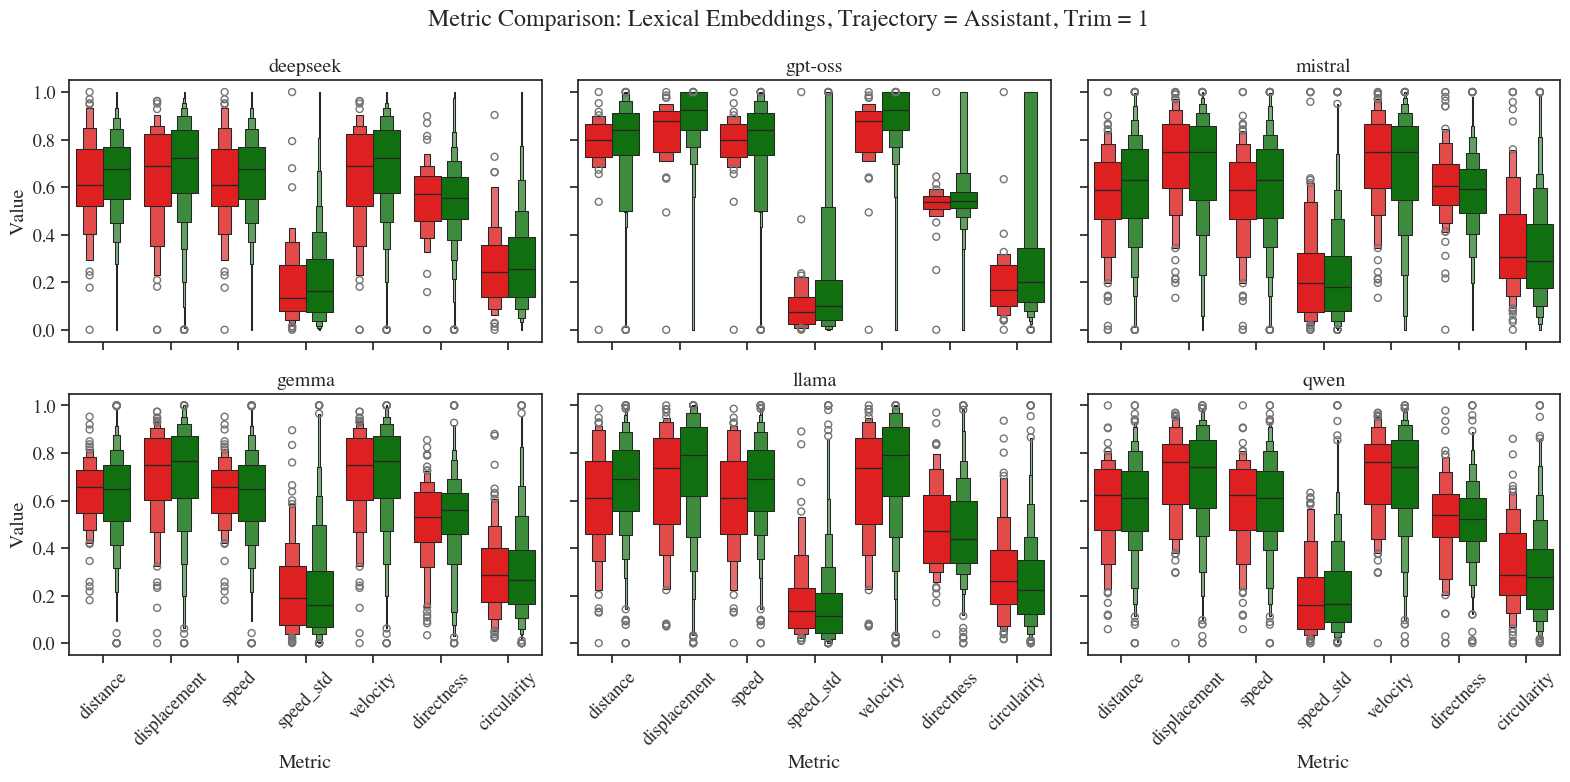

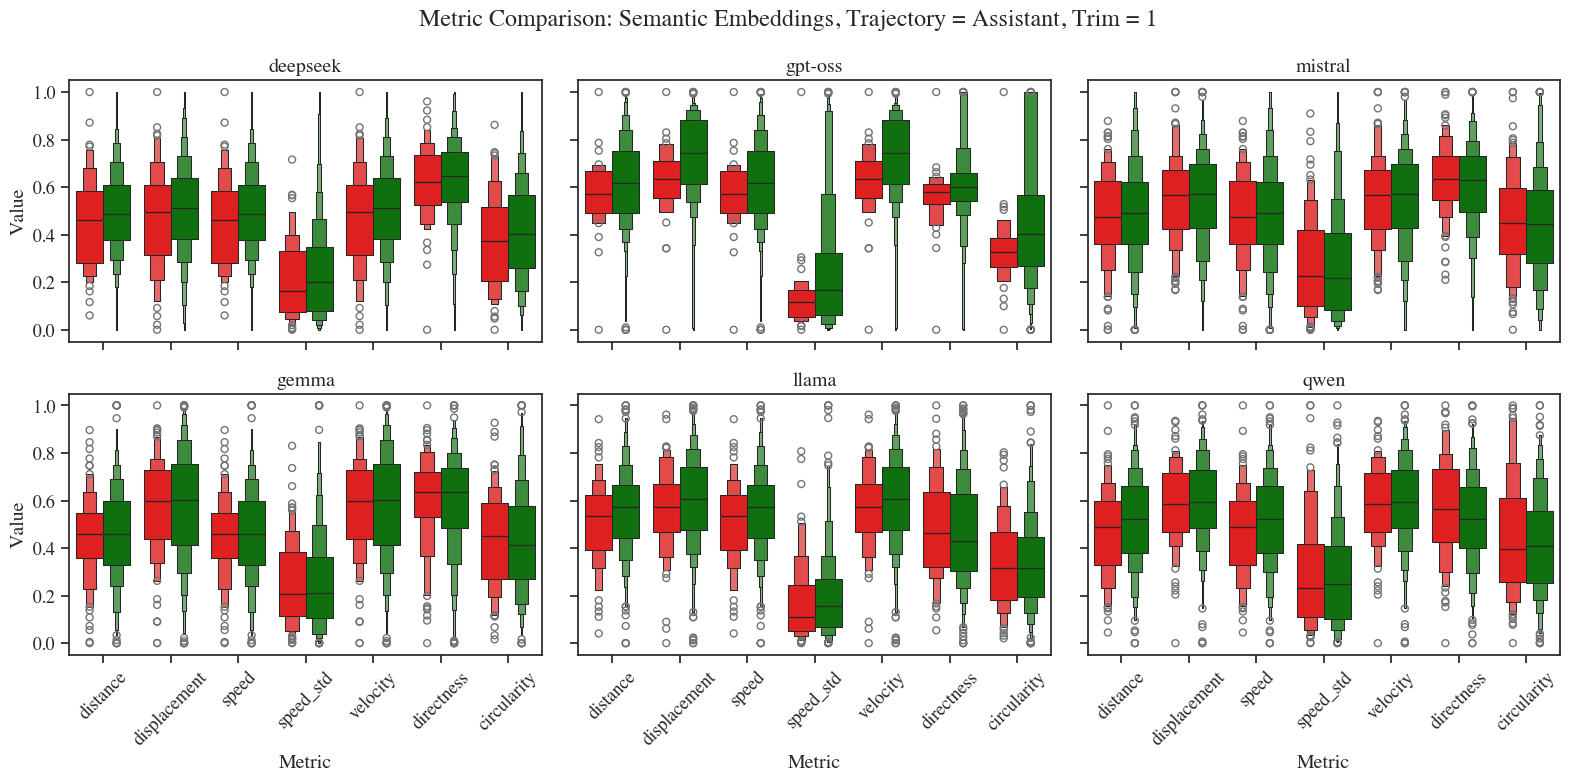

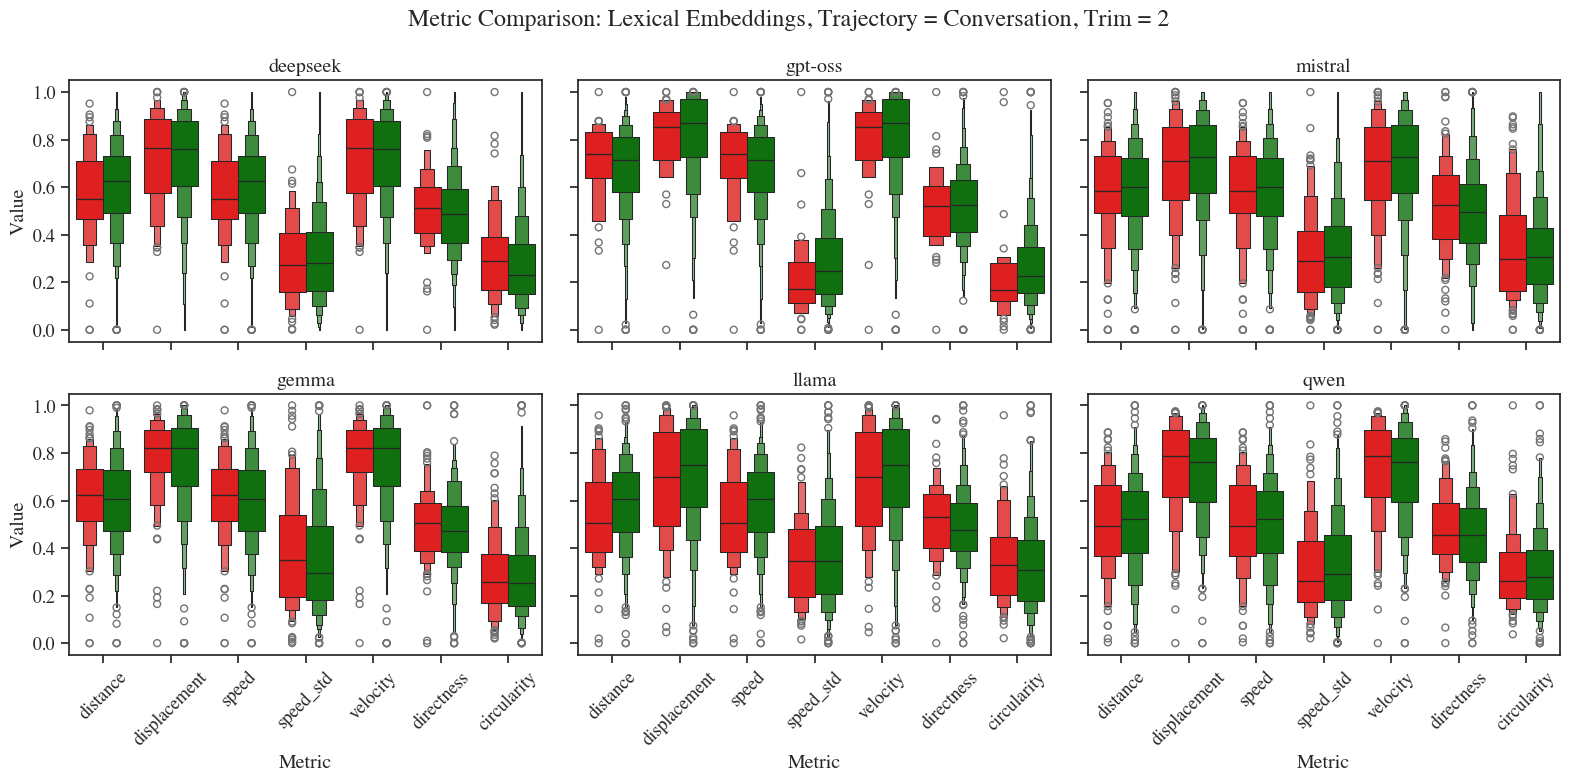

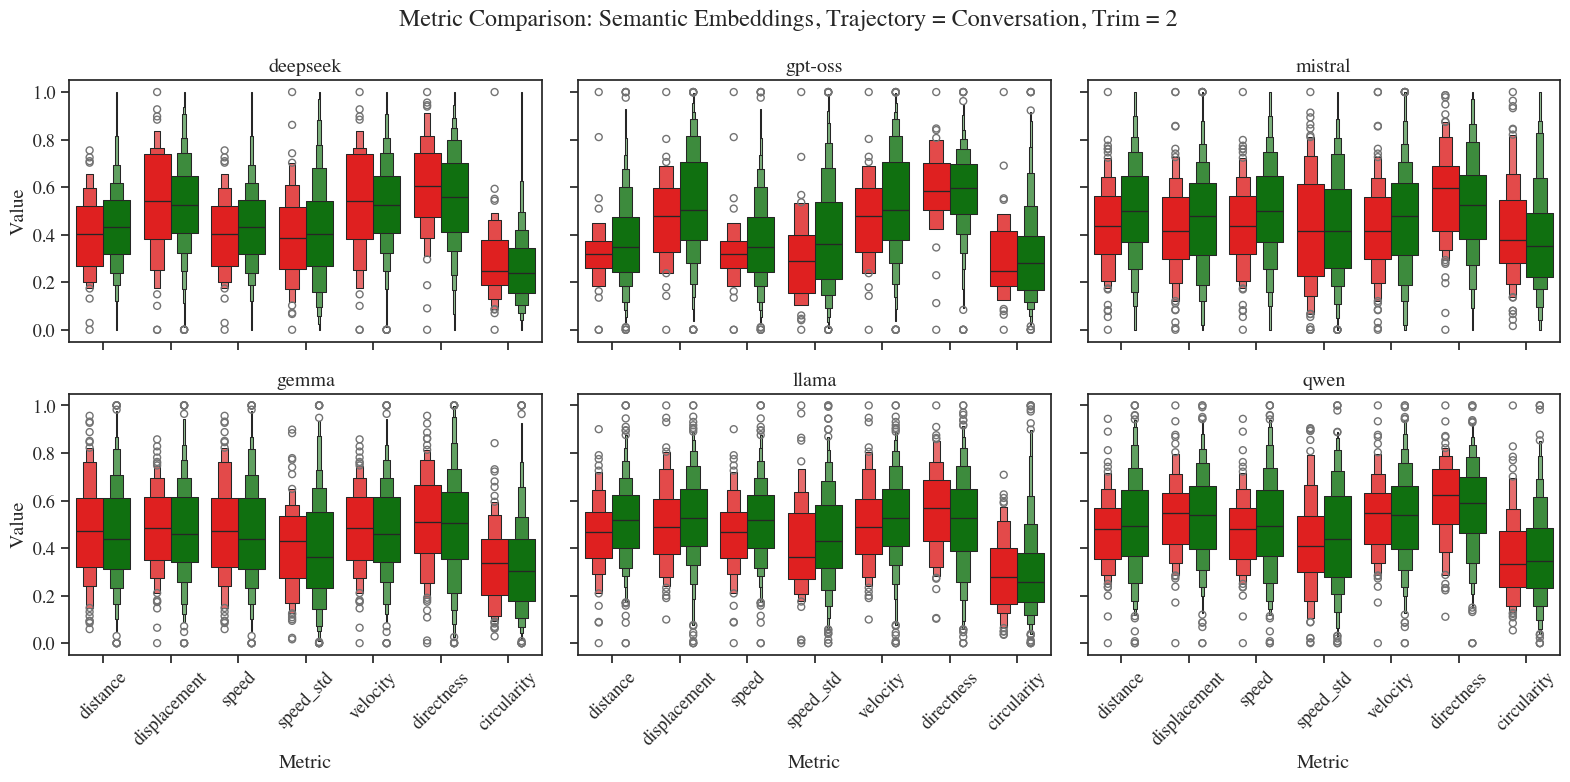

In [5]:
''' Metrics Comparison '''

from src.factory import METRICS_CONFIGS

def load(run_dir, filename):
    experiments = os.listdir(run_dir)
    results = []
    for experiment_name in experiments:
        experiment_dir = run_dir / experiment_name
        try:
            results.append(load_metrics(experiment_dir, filename))
        except Exception:
            continue
    
    results = pd.concat(results)
    results = results.melt(id_vars=["Objective Model", "Dataset", "Outcome"], value_vars=METRIC_NAMES, var_name="Metric", value_name="Value")

    return results

def plot(run_dir, filename, plot_metrics, plot_title, plot_name):

    results = load(run_dir, filename)

    num_models = len(results["Objective Model"].unique())
    fig, axs = plt.subplots(2, num_models//2, figsize=(16, 8), sharey=True, sharex=True)
    for i, model in enumerate(sorted(results["Objective Model"].unique())):
        ax = axs[i%2, i//2]
        sns.boxenplot(
            data=results[results["Objective Model"] == model],
            x="Metric",
            order=plot_metrics,
            y="Value",
            hue="Outcome",
            hue_order=["success", "failure"],
            ax=ax,
            palette=attack_result_colors,
            legend=False,
        )
        ax.set_title(model)
        ax.tick_params(axis='x', labelrotation=45)
    
    plt.suptitle(plot_title)
    plt.tight_layout()

    os.makedirs("./plots", exist_ok=True)
    plt.savefig(f"./plots/metric_comparison_{plot_name}.pdf")

run_path = Path("/Users/muberraozmen/Development/psycho-pass/experiments/objective_model_comparisons")

for metric_config in METRICS_CONFIGS:
    filename, embeddings, role, trim = metric_config["filename"], metric_config["embeddings"], metric_config["role"], metric_config["trim"]

    plot_metrics = METRIC_NAMES
    plot_title = f"Metric Comparison: {embeddings.capitalize()} Embeddings, Trajectory = {role.capitalize() if role else 'Conversation'}, Trim = {trim if trim else 'None'}"
    plot_name = filename.split(".")[0].replace("metrics_", "")
    try:
        plot(run_path, filename, plot_metrics, plot_title, plot_name)
    except Exception:
        print(f"Error plotting {filename}")
        continue
